### Merging csv files into one. First preprocessing step. DON'T RUN THIS PART AGAIN! 

In [40]:
import pandas as pd
import glob #read and join dataframes
import os

base_path = "/BPS/dataset/IoT"

benign_path = os.path.join(base_path, "benign") #benign folder
ddos_path = os.path.join(base_path, "ddos") #ddos folder

benign_files = glob.glob(os.path.join(benign_path, "*.csv")) #list csv files in benign folder 
ddos_files = glob.glob(os.path.join(ddos_path, "**", "*.csv"),recursive=True) #list csv files in ddos folder 


dfs = [] #dataframe empty list

for f in benign_files:
    df_tmp = pd.read_csv(f)
    df_tmp["traffic_class"] = "benign"
    df_tmp["attack_type"] = "benign"
    dfs.append(df_tmp)

for f in ddos_files:
    df_tmp = pd.read_csv(f)
    df_tmp["traffic_class"] = "ddos"
    df_tmp["attack_type"] = os.path.basename(f) #returns only the filename 
    dfs.append(df_tmp)

df_iot = pd.concat(dfs, ignore_index=True)

df_iot.shape


(3889716, 86)

In [41]:
df_iot["traffic_class"].value_counts()


traffic_class
ddos      3491386
benign     398330
Name: count, dtype: int64

# Start from here

In [11]:
import pandas as pd
import numpy as np
import os
# load the dataset
df_iot = pd.read_csv(
    r"D:\BPS\dataset\IoT\iot_benign_ddos_full.csv"
)


### Check if I must include this in the result because these features are not relevant to the analysis overall. 

In [12]:
df_iot = df_iot.replace([np.inf, -np.inf], np.nan)

In [13]:
df_iot = df_iot.dropna(subset=["Flow Bytes/s", "Flow Packets/s"])

In [14]:
X_iot = df_iot.select_dtypes(include=[np.number]).copy()

In [15]:
stats_tbl = X_iot.agg(["mean", "median", "std", "var"]).T
stats_tbl_sorted = stats_tbl.sort_values("std", ascending=False)

pd.set_option('display.max_rows', None)

display(stats_tbl_sorted)

,mean,median,std,var
Fwd IAT Total,3.360420e+07,6.364618e+06,4.030071e+07,1.624147e+15
Flow Duration,3.478896e+07,1.084359e+07,4.005618e+07,1.604498e+15
Idle Max,3.015280e+07,6.070768e+06,3.744531e+07,1.402151e+15
Fwd IAT Max,2.954536e+07,3.863006e+06,3.740926e+07,1.399452e+15
Fwd IAT Min,2.644721e+07,4.581000e+04,3.735087e+07,1.395087e+15
Flow IAT Max,3.051164e+07,6.070768e+06,3.716672e+07,1.381365e+15
Idle Min,2.869220e+07,5.494751e+06,3.715169e+07,1.380248e+15
Idle Mean,2.938065e+07,5.984221e+06,3.709433e+07,1.375989e+15
Fwd IAT Mean,2.756193e+07,2.088042e+06,3.704975e+07,1.372684e+15
Flow IAT Min,2.605589e+07,9.904820e+05,3.690315e+07,1.361842e+15


In [16]:
df_iot.shape[1]

86

In [17]:
df_iot.select_dtypes(include='number').shape[1]

79

In [18]:
np.isinf(df_iot["Flow Bytes/s"]).sum(), np.isinf(df_iot["Flow Packets/s"]).sum()

(0, 0)

In [19]:
np.isinf(X_iot).sum().sum()

0

In [20]:
top_dst_ports = (
    df_iot["Dst Port"]
    .value_counts()
    .head(20)
)

top_dst_ports

Dst Port
6668     877910
53       353846
554      313969
443      284921
8080     224747
80       149734
8008      89392
1443      83181
55442     77306
32100     66737
10002     63168
8009      49636
4070      41673
8886      33578
6667      28261
0         27439
55443     20727
5353      11334
123       11271
1900       8207
Name: count, dtype: int64

In [21]:
top_src_ports = (
    df_iot["Src Port"]
    .value_counts()
    .head(20)
)

top_src_ports

Src Port
80       586591
53       317847
443       35821
0         27450
49154     14638
5353      11164
55443      8763
1900       6721
67         5011
45855      2557
60000      2516
8886       2110
8800       2095
123        2014
56700      1983
10101      1977
32100      1973
37020      1789
68         1760
55444      1694
Name: count, dtype: int64

In [22]:
benign_ports = (
    df_iot[df_iot["traffic_class"] == "benign"]["Dst Port"]
    .value_counts()
    .head(10)
)

attack_ports = (
    df_iot[df_iot["traffic_class"] == "ddos"]["Dst Port"]
    .value_counts()
    .head(10)
)

print("Top-10 benign ports")
print(benign_ports)

print("\nTop-10 attack ports")
print(attack_ports)

Top-10 benign ports
Dst Port
53       122795
443       61823
32100     43662
80        24049
6667      14876
8886      13835
0          8242
5353       7006
55443      5636
1900       4626
Name: count, dtype: int64

Top-10 attack ports
Dst Port
6668     877910
554      313969
53       231051
8080     224747
443      223098
80       125685
8008      89392
1443      83181
55442     77306
10002     63168
Name: count, dtype: int64


In [23]:
# sum of bwd packets and fwd packets
df_iot["Total Packets"] = (
    df_iot["Fwd Packets/s"] +
    df_iot["Bwd Packets/s"]
)

# group by dst port
dst_port_packets = (
    df_iot
    .groupby("Dst Port")["Total Packets"]
    .sum()
    .sort_values(ascending=False)
)

print("\nTop 20 ports by Total packets:\n")
display(dst_port_packets.head(20))


# check total packets, grouped by dst ports in eac

benign_packets = (
    df_iot[df_iot["traffic_class"] == "benign"]
    .groupby("Dst Port")["Total Packets"]
    .sum()
    .sort_values(ascending=False)
)

attack_packets = (
    df_iot[df_iot["traffic_class"] == "ddos"]
    .groupby("Dst Port")["Total Packets"]
    .sum()
    .sort_values(ascending=False)
)

print("\nTop benign ports (volume):\n")
display(benign_packets.head(10))

print("\nTop attack ports (volume):\n")
display(attack_packets.head(10))


# comparison table 
comparison_port_volume_traffic = pd.DataFrame({
    "benign_packets": benign_packets,
    "attack_packets": attack_packets
}).fillna(0)

# attack sorting
comparison_port_volume_traffic = comparison_port_volume_traffic.sort_values(
    by="attack_packets",
    ascending=False
)

print("\nComparison table (top 10 ports):\n")
display(comparison_port_volume_traffic.head(10))




Top 20 ports by Total packets:



Dst Port
443      6.939475e+09
4431     1.633720e+09
55443    1.116304e+09
80       1.001142e+09
1883     3.688608e+08
10008    3.648035e+08
9999     2.961528e+08
53       2.648828e+08
8886     1.903254e+08
20443    1.834658e+08
1900     1.347356e+08
8883     1.330091e+08
4070     9.103968e+07
1982     7.979244e+07
5223     6.213907e+07
6668     5.565527e+07
8009     5.078140e+07
5353     4.864186e+07
0        4.533470e+07
8800     3.944023e+07
Name: Total Packets, dtype: float64


Top benign ports (volume):



Dst Port
443      1.687092e+09
4431     1.538767e+09
55443    7.613764e+07
1982     4.914248e+07
9999     4.307353e+07
80       2.371881e+07
50000    2.350138e+07
53       1.576729e+07
56700    1.517229e+07
8009     1.369658e+07
Name: Total Packets, dtype: float64


Top attack ports (volume):



Dst Port
443      5.252382e+09
55443    1.040167e+09
80       9.774235e+08
1883     3.668509e+08
10008    3.648035e+08
9999     2.530793e+08
53       2.491155e+08
8886     1.903208e+08
20443    1.834658e+08
8883     1.329960e+08
Name: Total Packets, dtype: float64


Comparison table (top 10 ports):



,benign_packets,attack_packets
Dst Port,,
443,1.687092e+09,5.252382e+09
55443,7.613764e+07,1.040167e+09
80,2.371881e+07,9.774235e+08
1883,2.009953e+06,3.668509e+08
10008,0.000000e+00,3.648035e+08
9999,4.307353e+07,2.530793e+08
53,1.576729e+07,2.491155e+08
8886,4.549119e+03,1.903208e+08
20443,0.000000e+00,1.834658e+08


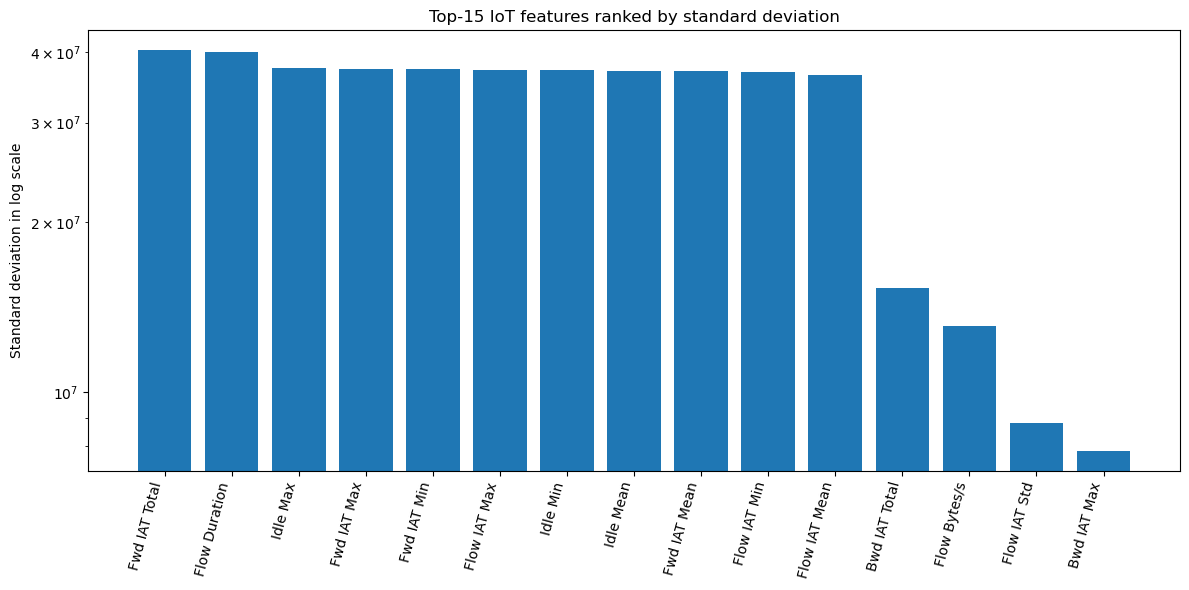

In [24]:
import matplotlib.pyplot as plt


# top 15 std
top15_std = stats_tbl_sorted.head(15).copy()

plt.figure(figsize=(12, 6))
plt.bar(top15_std.index, top15_std["std"])
plt.yscale("log") 
plt.xticks(rotation=75, ha="right")
plt.ylabel("Standard deviation in log scale")
plt.title("Top-15 IoT features ranked by standard deviation")
plt.tight_layout()
plt.savefig("Top-15 IoT features ranked by standard deviation", dpi=300, bbox_inches="tight")
plt.show()
 

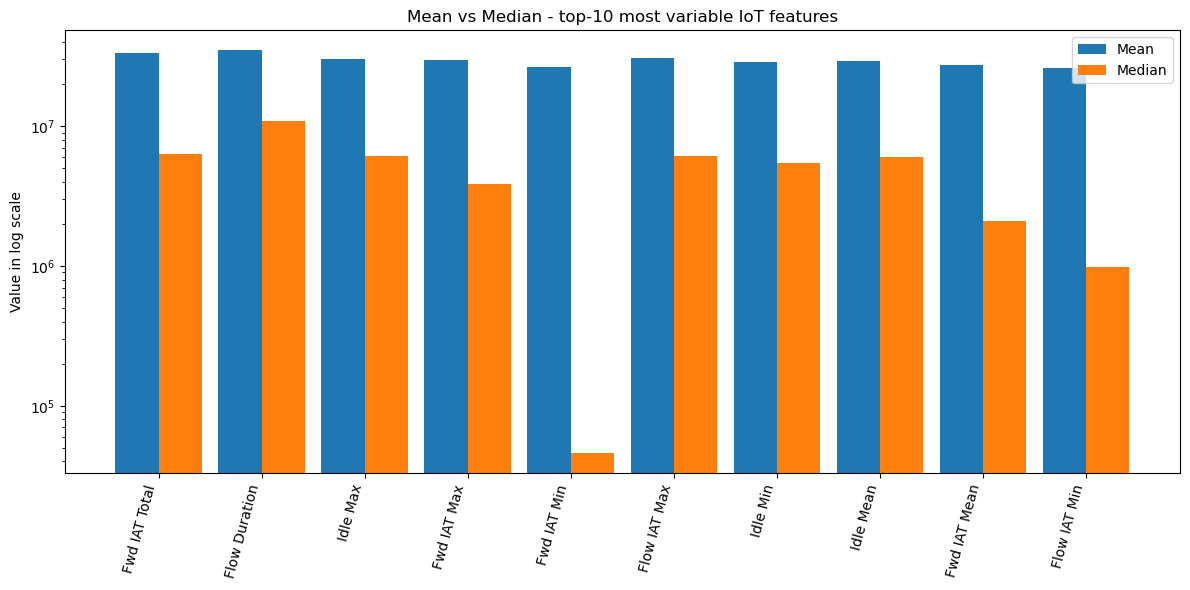

In [25]:
# Mean x median 

top10 = stats_tbl_sorted.head(10).copy()

x = np.arange(len(top10.index))
width = 0.42

plt.figure(figsize=(12, 6))
plt.bar(x - width/2, top10["mean"], width, label="Mean")
plt.bar(x + width/2, top10["median"], width, label="Median")
plt.yscale("log")  
plt.xticks(x, top10.index, rotation=75, ha="right")
plt.ylabel("Value in log scale")
plt.title("Mean vs Median - top-10 most variable IoT features")
plt.legend()
plt.tight_layout()
plt.savefig("Mean vs Median - top-10 most variable IoT features", dpi=300, bbox_inches="tight")
plt.show()

In [26]:
top_features_iot = stats_tbl_sorted.index[:10].tolist() #Top standard deviation
top_features_iot


['Fwd IAT Total',
 'Flow Duration',
 'Idle Max',
 'Fwd IAT Max',
 'Fwd IAT Min',
 'Flow IAT Max',
 'Idle Min',
 'Idle Mean',
 'Fwd IAT Mean',
 'Flow IAT Min']

In [27]:
outlier_summary_iot = {} #remove only Not a Number values 

for f in top_features_iot:
    x = X_iot[f].dropna()
    q1, q3 = x.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outlier_rate = ((x < lower) | (x > upper)).mean()
    outlier_summary_iot[f] = outlier_rate

outlier_rate_tbl_iot = (
    pd.Series(outlier_summary_iot, name="outlier_rate")
    .sort_values(ascending=False)
)

outlier_rate_tbl_iot


Fwd IAT Total    0.0
Flow Duration    0.0
Idle Max         0.0
Fwd IAT Max      0.0
Fwd IAT Min      0.0
Flow IAT Max     0.0
Idle Min         0.0
Idle Mean        0.0
Fwd IAT Mean     0.0
Flow IAT Min     0.0
Name: outlier_rate, dtype: float64

## Which features have similar behavior patterns across IoT and IIoT datasets?

In [28]:
top_features_iot = stats_tbl_sorted.index[:10].tolist()



In [29]:
corr_iot = X_iot[top_features_iot].corr(method="pearson")


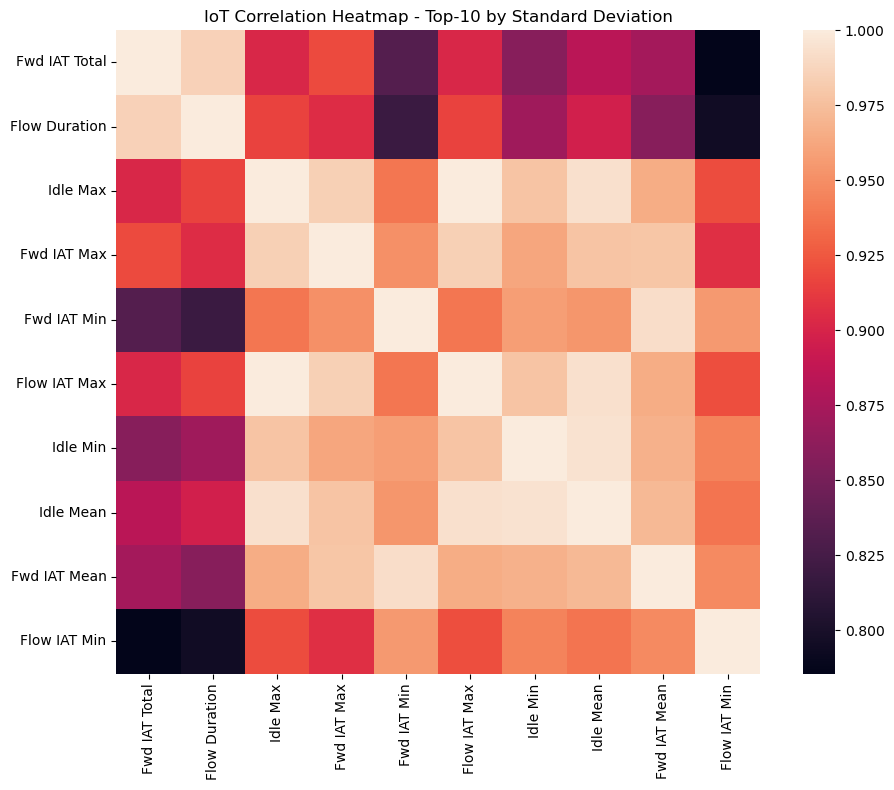

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_iot,
    cmap="rocket",
    annot=False,
    square=True
)
plt.title("IoT Correlation Heatmap - Top-10 by Standard Deviation")
plt.tight_layout()
plt.savefig("IoT Correlation Heatmap - Top-10 by Standard Deviation", dpi=300, bbox_inches="tight")
plt.show()


In [31]:
corr_pairs_iot = (
    corr_iot.abs()
    .where(lambda x: x < 1.0)
    .stack()
    .sort_values(ascending=False)
)

corr_pairs_iot.head(20)


Flow IAT Max   Idle Max         0.999721
Idle Max       Flow IAT Max     0.999721
Idle Min       Idle Mean        0.994842
Idle Mean      Idle Min         0.994842
               Idle Max         0.993637
Idle Max       Idle Mean        0.993637
Idle Mean      Flow IAT Max     0.993437
Flow IAT Max   Idle Mean        0.993437
Fwd IAT Mean   Fwd IAT Min      0.992364
Fwd IAT Min    Fwd IAT Mean     0.992364
Fwd IAT Total  Flow Duration    0.985459
Flow Duration  Fwd IAT Total    0.985459
Fwd IAT Max    Flow IAT Max     0.984497
Flow IAT Max   Fwd IAT Max      0.984497
Fwd IAT Max    Idle Max         0.984344
Idle Max       Fwd IAT Max      0.984344
Fwd IAT Max    Fwd IAT Mean     0.978725
Fwd IAT Mean   Fwd IAT Max      0.978725
Idle Mean      Fwd IAT Max      0.977717
Fwd IAT Max    Idle Mean        0.977717
dtype: float64

### Add this to a table with a column explaning why they are the redudant. Ex: Flow IAT Max measure Flow Inter-Arrival Time Max, which is the biggest interval between two consecutive packages. Idle Max corresponds to inactivity period. They are measuring the same thing. 

### Repeat the same global statistical analysis by protocol. 

In [20]:

# os.listdir(r"D:\BPS\dataset\IoT")


In [32]:
import pandas as pd

df = pd.read_csv(r"D:\BPS\dataset\IoT\iot_benign_ddos_full.csv")


In [33]:
list(df.columns)



['Flow ID',
 'Src IP',
 'Src Port',
 'Dst IP',
 'Dst Port',
 'Protocol',
 'Timestamp',
 'Flow Duration',
 'Total Fwd Packet',
 'Total Bwd packets',
 'Total Length of Fwd Packet',
 'Total Length of Bwd Packet',
 'Fwd Packet Length Max',
 'Fwd Packet Length Min',
 'Fwd Packet Length Mean',
 'Fwd Packet Length Std',
 'Bwd Packet Length Max',
 'Bwd Packet Length Min',
 'Bwd Packet Length Mean',
 'Bwd Packet Length Std',
 'Flow Bytes/s',
 'Flow Packets/s',
 'Flow IAT Mean',
 'Flow IAT Std',
 'Flow IAT Max',
 'Flow IAT Min',
 'Fwd IAT Total',
 'Fwd IAT Mean',
 'Fwd IAT Std',
 'Fwd IAT Max',
 'Fwd IAT Min',
 'Bwd IAT Total',
 'Bwd IAT Mean',
 'Bwd IAT Std',
 'Bwd IAT Max',
 'Bwd IAT Min',
 'Fwd PSH Flags',
 'Bwd PSH Flags',
 'Fwd URG Flags',
 'Bwd URG Flags',
 'Fwd Header Length',
 'Bwd Header Length',
 'Fwd Packets/s',
 'Bwd Packets/s',
 'Packet Length Min',
 'Packet Length Max',
 'Packet Length Mean',
 'Packet Length Std',
 'Packet Length Variance',
 'FIN Flag Count',
 'SYN Flag Count',
 'R

In [39]:
df["Protocol"].dtype
df["Protocol"].unique()
df["Protocol"].value_counts()


Protocol
6     3236935
17     625349
0       27432
Name: count, dtype: int64

In [40]:
protocol_percent = df["Protocol"].value_counts(normalize=True) * 100
print(protocol_percent)

Protocol
6     83.217772
17    16.076984
0      0.705244
Name: proportion, dtype: float64


In [43]:
df_proto = df_iot[df_iot["Protocol"].isin([6, 17])].copy()

df_tcp = df_proto[df_proto["Protocol"] == 6].copy()
df_udp = df_proto[df_proto["Protocol"] == 17].copy()

print("TCP shape:", df_tcp.shape)
print("UDP shape:", df_udp.shape)

TCP shape: (3234943, 87)
UDP shape: (625282, 87)


In [44]:
total = len(df_tcp) + len(df_udp)

tcp_percent = (len(df_tcp) / total) * 100
udp_percent = (len(df_udp) / total) * 100

print(f"TCP: {tcp_percent:.2f}%")
print(f"UDP: {udp_percent:.2f}%")

TCP: 83.80%
UDP: 16.20%


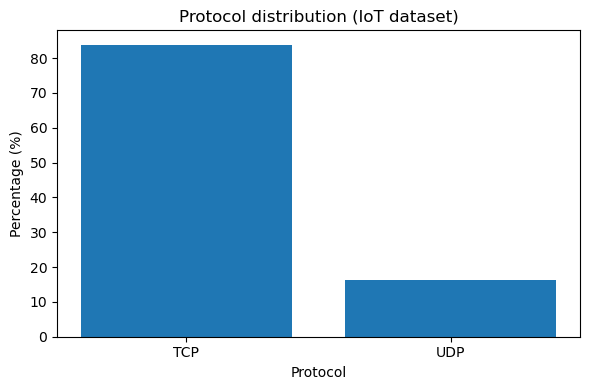

In [46]:
total = len(df_tcp) + len(df_udp)

protocol_percent = {
    "TCP": (len(df_tcp) / total) * 100,
    "UDP": (len(df_udp) / total) * 100
}

plt.figure(figsize=(6, 4))
plt.bar(protocol_percent.keys(), protocol_percent.values())

plt.xlabel("Protocol")
plt.ylabel("Percentage (%)")
plt.title("Protocol distribution (IoT dataset)")

plt.tight_layout()
plt.show()

In [47]:

num_cols_proto = df_proto.select_dtypes(include=[np.number]).columns.tolist()

#remove protocol from the statistics 
if "Protocol" in num_cols_proto:
    num_cols_proto.remove("Protocol")

X_tcp = df_tcp[num_cols_proto]
X_udp = df_udp[num_cols_proto]



### How important features are inside of a protocol

In [48]:
#Descriptive statistics for both protocols
stats_tcp = X_tcp.agg(["mean", "median", "std", "var"]).T
stats_udp = X_udp.agg(["mean", "median", "std", "var"]).T

#Standard deviation
stats_tcp_sorted = stats_tcp.sort_values("std", ascending=False)
stats_udp_sorted = stats_udp.sort_values("std", ascending=False)

print("\nTop-15 TCP features by Standard deviation:")
display(stats_tcp_sorted.head(15))

print("\nTop-15 UDP features by Standard deviation:")
display(stats_udp_sorted.head(15))




Top-15 TCP features by Standard deviation:


,mean,median,std,var
Fwd IAT Total,3.698914e+07,1.953850e+07,4.023357e+07,1.618740e+15
Flow Duration,3.837431e+07,2.385623e+07,3.982926e+07,1.586370e+15
Fwd IAT Min,3.128439e+07,1.072248e+06,3.899316e+07,1.520466e+15
Fwd IAT Max,3.426218e+07,1.361863e+07,3.867051e+07,1.495409e+15
Fwd IAT Mean,3.241654e+07,6.432857e+06,3.858781e+07,1.489019e+15
Idle Max,3.506325e+07,1.741532e+07,3.856524e+07,1.487277e+15
Flow IAT Min,3.106433e+07,3.676744e+06,3.843973e+07,1.477613e+15
Idle Min,3.353251e+07,1.118047e+07,3.843734e+07,1.477429e+15
Idle Mean,3.427126e+07,1.550270e+07,3.829391e+07,1.466423e+15
Flow IAT Max,3.541330e+07,1.741532e+07,3.825693e+07,1.463593e+15



Top-15 UDP features by Standard deviation:


,mean,median,std,var
Flow Duration,1.496192e+07,175869.500000,3.413865e+07,1.165447e+15
Fwd IAT Total,1.480291e+07,0.000000,3.413738e+07,1.165361e+15
Bwd IAT Total,5.398631e+06,0.000000,1.913092e+07,3.659922e+14
Idle Max,5.081089e+06,0.000000,1.504476e+07,2.263449e+14
Fwd IAT Max,5.413890e+06,0.000000,1.499973e+07,2.249918e+14
Flow IAT Max,5.472459e+06,173701.000000,1.493854e+07,2.231598e+14
Idle Mean,4.477094e+06,0.000000,1.349731e+07,1.821774e+14
Idle Min,4.085882e+06,0.000000,1.296429e+07,1.680728e+14
Flow Bytes/s,6.461111e+05,700.277558,1.236220e+07,1.528241e+14
Fwd IAT Mean,3.321729e+06,0.000000,9.800838e+06,9.605643e+13


In [49]:

shared_features = stats_tcp.index.intersection(stats_udp.index)

# straightforward comparison  
protocol_comparison = pd.DataFrame({
    "std_tcp": stats_tcp.loc[shared_features, "std"],
    "std_udp": stats_udp.loc[shared_features, "std"],
    "median_tcp": stats_tcp.loc[shared_features, "median"],
    "median_udp": stats_udp.loc[shared_features, "median"],
})

# diff
protocol_comparison["std_diff"] = (
    protocol_comparison["std_tcp"] - protocol_comparison["std_udp"]
).abs()

protocol_comparison["median_diff"] = (
    protocol_comparison["median_tcp"] - protocol_comparison["median_udp"]
).abs()

# rak of features that are protocol dependent - This step took into consideration shared features to both TCP and UDP 
protocol_comparison_sorted = protocol_comparison.sort_values(
    by="std_diff", ascending=False
)

print("\nTop protocol-dependent features:")
display(protocol_comparison_sorted.head(15))


Top protocol-dependent features:


,std_tcp,std_udp,median_tcp,median_udp,std_diff,median_diff
Flow IAT Min,3.843973e+07,6.616199e+06,3.676744e+06,89052.0,3.182353e+07,3.587692e+06
Flow IAT Mean,3.789472e+07,7.818341e+06,9.128181e+06,159587.0,3.007638e+07,8.968594e+06
Fwd IAT Min,3.899316e+07,8.970830e+06,1.072248e+06,0.0,3.002233e+07,1.072248e+06
Fwd IAT Mean,3.858781e+07,9.800838e+06,6.432857e+06,0.0,2.878697e+07,6.432857e+06
Idle Min,3.843734e+07,1.296429e+07,1.118047e+07,0.0,2.547305e+07,1.118047e+07
Idle Mean,3.829391e+07,1.349731e+07,1.550270e+07,0.0,2.479660e+07,1.550270e+07
Fwd IAT Max,3.867051e+07,1.499973e+07,1.361863e+07,0.0,2.367078e+07,1.361863e+07
Idle Max,3.856524e+07,1.504476e+07,1.741532e+07,0.0,2.352047e+07,1.741532e+07
Flow IAT Max,3.825693e+07,1.493854e+07,1.741532e+07,173701.0,2.331839e+07,1.724162e+07
Fwd IAT Total,4.023357e+07,3.413738e+07,1.953850e+07,0.0,6.096185e+06,1.953850e+07


In [50]:
tcp_only_features = stats_tcp.index.difference(stats_udp.index)
udp_only_features = stats_udp.index.difference(stats_tcp.index)

In [51]:
print("TCP-only:", len(tcp_only_features))
print("UDP-only:", len(udp_only_features))

TCP-only: 0
UDP-only: 0


In [52]:
low_variance_udp = stats_udp[stats_udp["std"] < 1e-5] 
display(low_variance_udp.head(20))

,mean,median,std,var
Fwd PSH Flags,0.0,0.0,0.0,0.0
Bwd PSH Flags,0.0,0.0,0.0,0.0
Fwd URG Flags,0.0,0.0,0.0,0.0
Bwd URG Flags,0.0,0.0,0.0,0.0
FIN Flag Count,0.0,0.0,0.0,0.0
SYN Flag Count,0.0,0.0,0.0,0.0
RST Flag Count,0.0,0.0,0.0,0.0
PSH Flag Count,0.0,0.0,0.0,0.0
ACK Flag Count,0.0,0.0,0.0,0.0
URG Flag Count,0.0,0.0,0.0,0.0


In [53]:
# check for features without variability in UDP protocol
# UDP only
low_variance_tcp = stats_tcp[stats_tcp["std"] < 1e-5]


display(low_variance_tcp.head(20))

,mean,median,std,var
Bwd PSH Flags,0.0,0.0,0.0,0.0
Fwd URG Flags,0.0,0.0,0.0,0.0
Bwd URG Flags,0.0,0.0,0.0,0.0
URG Flag Count,0.0,0.0,0.0,0.0
Fwd Bytes/Bulk Avg,0.0,0.0,0.0,0.0
Fwd Packet/Bulk Avg,0.0,0.0,0.0,0.0
Fwd Bulk Rate Avg,0.0,0.0,0.0,0.0


In [54]:
import matplotlib.pyplot as plt

df = low_variance_tcp.head(20).reset_index()
df.columns = ["Feature", "mean", "median", "std", "var"]

fig, ax = plt.subplots(figsize=(8, 6))
ax.axis("off")

table = ax.table(
    cellText=df.values,
    colLabels=df.columns,
    cellLoc="center",
    loc="center",
    bbox=[0.05, 0, 0.93, 1]  #fix error - Cutting F 
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.2)


nrows = len(df) + 1
for i in range(nrows):
    table[i, 0].set_width(0.55)  
    table[i, 1].set_width(0.12)
    table[i, 2].set_width(0.12)
    table[i, 3].set_width(0.10)
    table[i, 4].set_width(0.10)

plt.savefig("low_variance_tcp.png", dpi=300, bbox_inches="tight", pad_inches=0.2)
plt.close()

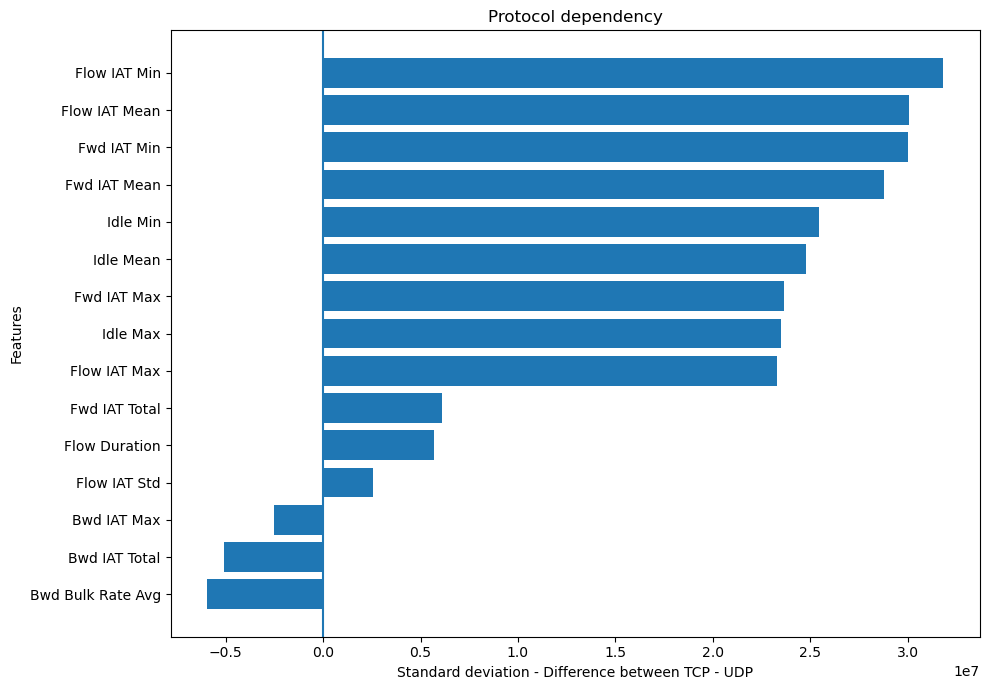

In [55]:
import matplotlib.pyplot as plt

# If value from diff is positive, it has greater variability in TCP, if negative, UDP. 
protocol_comparison["std_signed_diff"] = (
    protocol_comparison["std_tcp"] - protocol_comparison["std_udp"]
)

# select only 15 features 
df_plot = protocol_comparison.reindex(
    protocol_comparison["std_signed_diff"].abs().sort_values(ascending=False).index
).head(15)


df_plot = df_plot.sort_values("std_signed_diff")


plt.figure(figsize=(10, 7))
plt.barh(df_plot.index, df_plot["std_signed_diff"])


plt.axvline(0)

plt.xlabel("Standard deviation - Difference between TCP - UDP")
plt.ylabel("Features")
plt.title("Protocol dependency")
plt.tight_layout()
plt.savefig("Standard deviation - Difference between TCP - UDP", dpi=300, bbox_inches="tight")
plt.show()

In [56]:
for col in X_tcp.columns:
    tcp_unique = X_tcp[col].replace([np.inf, -np.inf], np.nan).dropna().nunique()
    udp_unique = X_udp[col].replace([np.inf, -np.inf], np.nan).dropna().nunique()
    
    if tcp_unique <= 1 or udp_unique <= 1:
        print(f"{col}: tcp_unique={tcp_unique}, udp_unique={udp_unique}")

Fwd PSH Flags: tcp_unique=2, udp_unique=1
Bwd PSH Flags: tcp_unique=1, udp_unique=1
Fwd URG Flags: tcp_unique=1, udp_unique=1
Bwd URG Flags: tcp_unique=1, udp_unique=1
FIN Flag Count: tcp_unique=4, udp_unique=1
SYN Flag Count: tcp_unique=37, udp_unique=1
RST Flag Count: tcp_unique=3, udp_unique=1
PSH Flag Count: tcp_unique=732, udp_unique=1
ACK Flag Count: tcp_unique=2276, udp_unique=1
URG Flag Count: tcp_unique=1, udp_unique=1
CWR Flag Count: tcp_unique=9, udp_unique=1
ECE Flag Count: tcp_unique=18, udp_unique=1
Fwd Bytes/Bulk Avg: tcp_unique=1, udp_unique=1
Fwd Packet/Bulk Avg: tcp_unique=1, udp_unique=1
Fwd Bulk Rate Avg: tcp_unique=1, udp_unique=1
FWD Init Win Bytes: tcp_unique=3495, udp_unique=1
Bwd Init Win Bytes: tcp_unique=3356, udp_unique=1
Fwd Seg Size Min: tcp_unique=11, udp_unique=1


### Best features to distinguish benign from ddos traffic 

In [58]:
X_benign = df_iot[df_iot["traffic_class"] == "benign"].copy()
X_ddos = df_iot[df_iot["traffic_class"] == "ddos"].copy()

In [59]:
X_benign = X_benign.drop(columns=["traffic_class"])
X_ddos = X_ddos.drop(columns=["traffic_class"])

In [60]:
print(df_iot["traffic_class"].value_counts(dropna=False))

traffic_class
ddos      3489459
benign     398198
Name: count, dtype: int64


In [61]:
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning, module="scipy")


# Rank-biserial correlation derived from Mann-Whitney U
def rank_biserial_from_u(u_stat, n1, n2):
    u_min = min(u_stat, n1 * n2 - u_stat)
    return 1 - (2 * u_min) / (n1 * n2)


# RBC Effect size classification
def classify_rbc(rbc):
    if pd.isna(rbc):
        return np.nan
    elif rbc >= 0.50:
        return "large"
    elif rbc >= 0.30:
        return "moderate"
    elif rbc >= 0.10:
        return "small"
    else:
        return "very_small"


# At this stage there are only numerical featues in the DF, but reinforce this
X = df_iot.select_dtypes(include=[np.number]).copy()


# defining target variable
y = df_iot["traffic_class"]

# Split benign and attack traffic
X_benign = X[y == "benign"]
X_attack = X[y == "ddos"]

results = []

for col in X.columns:
    benign_col = (
        pd.to_numeric(X_benign[col], errors="coerce")
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )

    attack_col = (
        pd.to_numeric(X_attack[col], errors="coerce")
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )

    # Skip features with too few samples or no variability
    if (
        len(benign_col) < 2 or
        len(attack_col) < 2 or
        benign_col.nunique() <= 1 or
        attack_col.nunique() <= 1
    ):
        continue

    # Mann-Whitney U test
    u_stat, _ = mannwhitneyu(benign_col, attack_col, alternative="two-sided")

    # Rank-biserial (RBC) effect size
    rbc = abs(rank_biserial_from_u(u_stat, len(benign_col), len(attack_col)))

    results.append({
        "feature": col,
        "effect_size_rbc": rbc,
        "effect_strength": classify_rbc(rbc),
        "median_benign": benign_col.median(),
        "median_attack": attack_col.median(),
        "mean_benign": benign_col.mean(),
        "mean_attack": attack_col.mean()
    })

results_df = (
    pd.DataFrame(results)
    .sort_values("effect_size_rbc", ascending=False)
    .reset_index(drop=True)
)

print("\nDesc. discriminative features' list:\n")
display(results_df.head(90))


Desc. discriminative features' list:



,feature,effect_size_rbc,effect_strength,median_benign,median_attack,mean_benign,mean_attack
0,Packet Length Mean,0.579188,large,46.666667,9.733333e+02,9.247204e+01,7.989019e+02
1,Average Packet Size,0.578926,large,62.000000,1.460000e+03,1.123678e+02,1.183844e+03
2,Packet Length Max,0.533857,large,70.000000,1.460000e+03,3.775505e+02,1.060484e+03
3,Flow IAT Min,0.502949,large,45696.500000,2.480818e+06,1.214346e+06,2.889067e+07
4,Protocol,0.493763,moderate,17.000000,6.000000e+00,1.268156e+01,7.161477e+00
5,Subflow Fwd Bytes,0.447861,moderate,0.000000,1.460000e+03,4.195651e+02,1.390385e+03
6,Total Bwd packets,0.424821,moderate,1.000000,0.000000e+00,1.188081e+01,2.224273e+01
7,Flow IAT Mean,0.421450,moderate,131797.500000,4.999528e+06,3.513524e+06,3.039092e+07
8,Flow Packets/s,0.389707,moderate,14.232318,3.166958e-01,1.599772e+04,1.345683e+04
9,Total Packets,0.389707,moderate,14.232318,3.166958e-01,1.599772e+04,1.345683e+04


# Feature exploration 

# The following cells contains feature exploration, such as correlation and statistical analysis across benign and ddos traffic. Results supports the feature selection for creating a reduced dataset. 

In [62]:
print(df.dtypes)

Feature     object
mean       float64
median     float64
std        float64
var        float64
dtype: object


In [63]:
df_iot["Flow Duration"].describe()

count    3.887657e+06
mean     3.478896e+07
std      4.005618e+07
min      1.000000e+00
25%      1.632810e+05
50%      1.084359e+07
75%      6.893234e+07
max      1.200000e+08
Name: Flow Duration, dtype: float64

In [64]:
df_iot.groupby("traffic_class")["Flow Duration"].describe()

,count,mean,std,min,25%,50%,75%,max
traffic_class,,,,,,,,
benign,398198.0,2.722361e+07,4.480818e+07,1.0,94962.25,292144.0,60001090.0,120000000.0
ddos,3489459.0,3.565227e+07,3.938530e+07,1.0,219971.50,15232479.0,69554678.5,120000000.0


In [65]:
df_iot[["Flow Duration", "Flow Bytes/s", "Flow Packets/s"]].corr()

,Flow Duration,Flow Bytes/s,Flow Packets/s
Flow Duration,1.000000,-0.017654,-0.077134
Flow Bytes/s,-0.017654,1.000000,0.193599
Flow Packets/s,-0.077134,0.193599,1.000000


In [66]:
# check results because previously some inf values were removed 
print(df_iot[["Flow Duration", "Flow Bytes/s", "Flow Packets/s"]].isna().sum())

Flow Duration     0
Flow Bytes/s      0
Flow Packets/s    0
dtype: int64


In [67]:
print(df_iot.dtypes)

Flow ID                        object
Src IP                         object
Src Port                        int64
Dst IP                         object
Dst Port                        int64
Protocol                        int64
Timestamp                      object
Flow Duration                   int64
Total Fwd Packet                int64
Total Bwd packets               int64
Total Length of Fwd Packet    float64
Total Length of Bwd Packet    float64
Fwd Packet Length Max         float64
Fwd Packet Length Min         float64
Fwd Packet Length Mean        float64
Fwd Packet Length Std         float64
Bwd Packet Length Max         float64
Bwd Packet Length Min         float64
Bwd Packet Length Mean        float64
Bwd Packet Length Std         float64
Flow Bytes/s                  float64
Flow Packets/s                float64
Flow IAT Mean                 float64
Flow IAT Std                  float64
Flow IAT Max                  float64
Flow IAT Min                  float64
Fwd IAT Tota

In [68]:
df_iot["Total Fwd Packet"].describe()

count    3.887657e+06
mean     1.844902e+02
std      8.352450e+03
min      1.000000e+00
25%      1.000000e+00
50%      2.000000e+00
75%      2.000000e+00
max      1.499573e+06
Name: Total Fwd Packet, dtype: float64

In [69]:
df_iot.groupby("traffic_class")["Total Fwd Packet"].describe()

,count,mean,std,min,25%,50%,75%,max
traffic_class,,,,,,,,
benign,398198.0,15.410509,157.139413,1.0,1.0,2.0,5.0,20031.0
ddos,3489459.0,203.784651,8815.780479,1.0,1.0,2.0,2.0,1499573.0


In [70]:
df_iot.groupby("traffic_class")["Total Bwd packets"].describe()

,count,mean,std,min,25%,50%,75%,max
traffic_class,,,,,,,,
benign,398198.0,11.880806,149.094929,0.0,1.0,1.0,4.0,20428.0
ddos,3489459.0,22.242732,3068.445508,0.0,0.0,0.0,1.0,1209556.0


In [71]:
df_iot.groupby("traffic_class")["Bwd Packet Length Max"].describe()

,count,mean,std,min,25%,50%,75%,max
traffic_class,,,,,,,,
benign,398198.0,231.511148,665.569108,0.0,2.0,44.0,127.0,17376.0
ddos,3489459.0,260.437925,563.787744,0.0,0.0,0.0,44.0,34752.0


In [72]:
df_iot.groupby("traffic_class")["Bwd Packet Length Min"].describe()

,count,mean,std,min,25%,50%,75%,max
traffic_class,,,,,,,,
benign,398198.0,43.617843,72.735018,0.0,0.0,20.0,51.0,4188.0
ddos,3489459.0,237.938318,528.789622,0.0,0.0,0.0,12.0,3323.0


In [73]:
df_iot.groupby("traffic_class")["Bwd Packet Length Std"].describe()

,count,mean,std,min,25%,50%,75%,max
traffic_class,,,,,,,,
benign,398198.0,65.023118,230.977623,0.0,0.0,0.0,1.005249,2427.480010
ddos,3489459.0,8.264215,72.979454,0.0,0.0,0.0,0.000000,4231.442993


In [74]:
df_iot["Total Bwd packets"].describe()

count    3.887657e+06
mean     2.118140e+01
std      2.907450e+03
min      0.000000e+00
25%      0.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.209556e+06
Name: Total Bwd packets, dtype: float64

In [75]:
df_iot[["Total Fwd Packet", "Total Bwd packets"]].corr()

,Total Fwd Packet,Total Bwd packets
Total Fwd Packet,1.000000,0.140621
Total Bwd packets,0.140621,1.000000


In [76]:
df_iot["Total Length of Fwd Packet"].describe()

count    3.887657e+06
mean     2.941913e+03
std      8.114227e+04
min      0.000000e+00
25%      0.000000e+00
50%      1.044000e+03
75%      2.920000e+03
max      1.973866e+07
Name: Total Length of Fwd Packet, dtype: float64

In [77]:
df_iot["Total Length of Bwd Packet"].describe()

count    3.887657e+06
mean     5.450956e+02
std      5.712806e+04
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      6.900000e+01
max      4.252113e+07
Name: Total Length of Bwd Packet, dtype: float64

In [78]:
df_iot[["Total Length of Bwd Packet", "Total Length of Fwd Packet"]].corr()

,Total Length of Bwd Packet,Total Length of Fwd Packet
Total Length of Bwd Packet,1.000000,0.001353
Total Length of Fwd Packet,0.001353,1.000000


In [79]:
df_iot.groupby("traffic_class")["Total Length of Bwd Packet"].describe()

,count,mean,std,min,25%,50%,75%,max
traffic_class,,,,,,,,
benign,398198.0,1715.279821,150099.597741,0.0,7.0,44.0,178.0,38260650.0
ddos,3489459.0,411.560619,32632.584496,0.0,0.0,0.0,48.0,42521126.0


In [80]:
df_iot.groupby("traffic_class")["Total Length of Fwd Packet"].describe()

,count,mean,std,min,25%,50%,75%,max
traffic_class,,,,,,,,
benign,398198.0,13637.063647,246813.427740,0.0,28.0,65.0,346.0,19738657.0
ddos,3489459.0,1721.440769,19219.226186,0.0,0.0,1460.0,2920.0,14914072.0


In [81]:
df_iot[[
    "Total Length of Fwd Packet",
    "Total Length of Bwd Packet",
    "Fwd Packet Length Min",
    "Fwd Packet Length Max",
    "Fwd Packet Length Mean",
    "Fwd Packet Length Std",
    "Bwd Packet Length Min",
    "Bwd Packet Length Max",
    "Bwd Packet Length Mean",
    "Bwd Packet Length Std"
]].corr()

,Total Length of Fwd Packet,Total Length of Bwd Packet,Fwd Packet Length Min,Fwd Packet Length Max,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Min,Bwd Packet Length Max,Bwd Packet Length Mean,Bwd Packet Length Std
Total Length of Fwd Packet,1.000000,0.001353,-0.002507,0.366356,0.044546,0.202735,-0.015595,0.044402,-0.015555,0.008789
Total Length of Bwd Packet,0.001353,1.000000,-0.009049,-0.002500,-0.008750,0.004896,0.006705,0.047847,0.023937,0.042956
Fwd Packet Length Min,-0.002507,-0.009049,1.000000,0.815830,0.991724,-0.204178,-0.410104,-0.425291,-0.424590,-0.130179
Fwd Packet Length Max,0.366356,-0.002500,0.815830,1.000000,0.869221,0.263446,-0.405033,-0.316017,-0.404933,0.000420
Fwd Packet Length Mean,0.044546,-0.008750,0.991724,0.869221,1.000000,-0.088283,-0.424206,-0.421393,-0.436611,-0.110184
Fwd Packet Length Std,0.202735,0.004896,-0.204178,0.263446,-0.088283,1.000000,-0.090869,0.073056,-0.063773,0.240286
Bwd Packet Length Min,-0.015595,0.006705,-0.410104,-0.405033,-0.424206,-0.090869,1.000000,0.848737,0.989453,-0.058416
Bwd Packet Length Max,0.044402,0.047847,-0.425291,-0.316017,-0.421393,0.073056,0.848737,1.000000,0.903229,0.452497
Bwd Packet Length Mean,-0.015555,0.023937,-0.424590,-0.404933,-0.436611,-0.063773,0.989453,0.903229,1.000000,0.068172
Bwd Packet Length Std,0.008789,0.042956,-0.130179,0.000420,-0.110184,0.240286,-0.058416,0.452497,0.068172,1.000000


In [82]:
df_iot[[
    "Total Length of Fwd Packet",
    "Total Length of Bwd Packet",
    "Fwd Packet Length Min",
    "Fwd Packet Length Max",
    "Fwd Packet Length Mean",
    "Fwd Packet Length Std",
    "Bwd Packet Length Min",
    "Bwd Packet Length Max",
    "Bwd Packet Length Mean",
    "Bwd Packet Length Std",
]].corr()

,Total Length of Fwd Packet,Total Length of Bwd Packet,Fwd Packet Length Min,Fwd Packet Length Max,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Min,Bwd Packet Length Max,Bwd Packet Length Mean,Bwd Packet Length Std
Total Length of Fwd Packet,1.000000,0.001353,-0.002507,0.366356,0.044546,0.202735,-0.015595,0.044402,-0.015555,0.008789
Total Length of Bwd Packet,0.001353,1.000000,-0.009049,-0.002500,-0.008750,0.004896,0.006705,0.047847,0.023937,0.042956
Fwd Packet Length Min,-0.002507,-0.009049,1.000000,0.815830,0.991724,-0.204178,-0.410104,-0.425291,-0.424590,-0.130179
Fwd Packet Length Max,0.366356,-0.002500,0.815830,1.000000,0.869221,0.263446,-0.405033,-0.316017,-0.404933,0.000420
Fwd Packet Length Mean,0.044546,-0.008750,0.991724,0.869221,1.000000,-0.088283,-0.424206,-0.421393,-0.436611,-0.110184
Fwd Packet Length Std,0.202735,0.004896,-0.204178,0.263446,-0.088283,1.000000,-0.090869,0.073056,-0.063773,0.240286
Bwd Packet Length Min,-0.015595,0.006705,-0.410104,-0.405033,-0.424206,-0.090869,1.000000,0.848737,0.989453,-0.058416
Bwd Packet Length Max,0.044402,0.047847,-0.425291,-0.316017,-0.421393,0.073056,0.848737,1.000000,0.903229,0.452497
Bwd Packet Length Mean,-0.015555,0.023937,-0.424590,-0.404933,-0.436611,-0.063773,0.989453,0.903229,1.000000,0.068172
Bwd Packet Length Std,0.008789,0.042956,-0.130179,0.000420,-0.110184,0.240286,-0.058416,0.452497,0.068172,1.000000


In [83]:
df_iot[[
    "Total Length of Fwd Packet",
    "Fwd Packet Length Min",
    "Fwd Packet Length Max",
    "Fwd Packet Length Mean",
    "Fwd Packet Length Std",
]].corr()

,Total Length of Fwd Packet,Fwd Packet Length Min,Fwd Packet Length Max,Fwd Packet Length Mean,Fwd Packet Length Std
Total Length of Fwd Packet,1.000000,-0.002507,0.366356,0.044546,0.202735
Fwd Packet Length Min,-0.002507,1.000000,0.815830,0.991724,-0.204178
Fwd Packet Length Max,0.366356,0.815830,1.000000,0.869221,0.263446
Fwd Packet Length Mean,0.044546,0.991724,0.869221,1.000000,-0.088283
Fwd Packet Length Std,0.202735,-0.204178,0.263446,-0.088283,1.000000


In [84]:
df_iot[[
    "Total Length of Bwd Packet",
    "Bwd Packet Length Min",
    "Bwd Packet Length Max",
    "Bwd Packet Length Mean",
    "Bwd Packet Length Std",
]].corr()

,Total Length of Bwd Packet,Bwd Packet Length Min,Bwd Packet Length Max,Bwd Packet Length Mean,Bwd Packet Length Std
Total Length of Bwd Packet,1.000000,0.006705,0.047847,0.023937,0.042956
Bwd Packet Length Min,0.006705,1.000000,0.848737,0.989453,-0.058416
Bwd Packet Length Max,0.047847,0.848737,1.000000,0.903229,0.452497
Bwd Packet Length Mean,0.023937,0.989453,0.903229,1.000000,0.068172
Bwd Packet Length Std,0.042956,-0.058416,0.452497,0.068172,1.000000


In [85]:
df_iot["Flow Bytes/s"].describe()

count    3.887657e+06
mean     2.658936e+05
std      1.307580e+07
min      0.000000e+00
25%      2.984068e+01
50%      6.047616e+01
75%      9.477977e+02
max      2.920000e+09
Name: Flow Bytes/s, dtype: float64

In [86]:
df_iot.groupby("traffic_class")["Flow Bytes/s"].describe()

,count,mean,std,min,25%,50%,75%,max
traffic_class,,,,,,,,
benign,398198.0,953413.628602,1.590836e+07,0.0,22.028411,612.109568,2248.888464,1.583000e+09
ddos,3489459.0,187437.520691,1.271014e+07,0.0,29.900478,56.325769,758.140737,2.920000e+09


In [87]:
df_iot["Flow Packets/s"].describe()

count    3.887657e+06
mean     1.371709e+04
std      1.543831e+05
min      1.666667e-02
25%      3.452950e-02
50%      4.362901e-01
75%      2.196209e+01
max      5.000000e+06
Name: Flow Packets/s, dtype: float64

In [88]:
df_iot.groupby("traffic_class")["Flow Packets/s"].describe()

,count,mean,std,min,25%,50%,75%,max
traffic_class,,,,,,,,
benign,398198.0,15997.721797,158300.276569,0.016668,0.376451,14.232318,31.722366,3000000.0
ddos,3489459.0,13456.833817,153927.596147,0.016667,0.031661,0.316696,16.502467,5000000.0


In [89]:
df_iot["Flow IAT Mean"].describe()

count    3.887657e+06
mean     2.763797e+07
std      3.651021e+07
min      2.500000e-01
25%      6.739700e+04
50%      3.491945e+06
75%      5.514487e+07
max      1.200000e+08
Name: Flow IAT Mean, dtype: float64

In [90]:
df_iot["Flow IAT Std"].describe()

count    3.887657e+06
mean     2.354757e+06
std      8.805325e+06
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      3.286721e+03
max      8.484821e+07
Name: Flow IAT Std, dtype: float64

In [91]:
df_iot["Flow IAT Max"].describe()

count    3.887657e+06
mean     3.051164e+07
std      3.716672e+07
min      1.000000e+00
25%      1.399940e+05
50%      6.070768e+06
75%      6.027807e+07
max      1.200000e+08
Name: Flow IAT Max, dtype: float64

In [92]:
df_iot["Flow IAT Min"].describe()

count    3.887657e+06
mean     2.605589e+07
std      3.690315e+07
min     -5.000000e+00
25%      3.506000e+04
50%      9.904820e+05
75%      5.410926e+07
max      1.200000e+08
Name: Flow IAT Min, dtype: float64

In [93]:
df_iot[[
    "Flow IAT Min",
    "Flow IAT Max",
    "Flow IAT Mean",
    "Flow IAT Std",
]].corr()

,Flow IAT Min,Flow IAT Max,Flow IAT Mean,Flow IAT Std
Flow IAT Min,1.000000,0.920772,0.986384,-0.152613
Flow IAT Max,0.920772,1.000000,0.967006,0.227590
Flow IAT Mean,0.986384,0.967006,1.000000,0.010066
Flow IAT Std,-0.152613,0.227590,0.010066,1.000000


In [94]:
df_iot["Fwd IAT Min"].describe()

count    3.887657e+06
mean     2.644721e+07
std      3.735087e+07
min     -5.000000e+00
25%      0.000000e+00
50%      4.581000e+04
75%      5.514905e+07
max      1.200000e+08
Name: Fwd IAT Min, dtype: float64

In [95]:
df_iot["Fwd IAT Mean"].describe()

count    3.887657e+06
mean     2.756193e+07
std      3.704975e+07
min      0.000000e+00
25%      0.000000e+00
50%      2.088042e+06
75%      5.574762e+07
max      1.200000e+08
Name: Fwd IAT Mean, dtype: float64

In [96]:
df_iot["Fwd IAT Max"].describe()

count    3.887657e+06
mean     2.954536e+07
std      3.740926e+07
min      0.000000e+00
25%      0.000000e+00
50%      3.863006e+06
75%      5.997274e+07
max      1.200000e+08
Name: Fwd IAT Max, dtype: float64

In [97]:
df_iot["Fwd IAT Mean"].describe()

count    3.887657e+06
mean     2.756193e+07
std      3.704975e+07
min      0.000000e+00
25%      0.000000e+00
50%      2.088042e+06
75%      5.574762e+07
max      1.200000e+08
Name: Fwd IAT Mean, dtype: float64

In [98]:
df_iot["Fwd IAT Std"].describe()

count    3.887657e+06
mean     1.580330e+06
std      6.553606e+06
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      8.484821e+07
Name: Fwd IAT Std, dtype: float64

In [99]:
df_iot[[
    "Fwd IAT Min",
    "Fwd IAT Max",
    "Fwd IAT Mean",
    "Fwd IAT Std",
    "Fwd IAT Total"
]].corr()

,Fwd IAT Min,Fwd IAT Max,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Total
Fwd IAT Min,1.000000,0.951110,0.992364,-0.126852,0.832863
Fwd IAT Max,0.951110,1.000000,0.978725,0.172592,0.919423
Fwd IAT Mean,0.992364,0.978725,1.000000,-0.006481,0.873492
Fwd IAT Std,-0.126852,0.172592,-0.006481,1.000000,0.265469
Fwd IAT Total,0.832863,0.919423,0.873492,0.265469,1.000000


In [100]:
df_iot.groupby("traffic_class")["Fwd IAT Std"].describe()

,count,mean,std,min,25%,50%,75%,max
traffic_class,,,,,,,,
benign,398198.0,3.837427e+06,1.033231e+07,0.0,0.0,0.0,103034.885395,8.484821e+07
ddos,3489459.0,1.322762e+06,5.917838e+06,0.0,0.0,0.0,0.000000,8.480757e+07


In [101]:
df_iot.groupby("traffic_class")["Fwd IAT Total"].describe()

,count,mean,std,min,25%,50%,75%,max
traffic_class,,,,,,,,
benign,398198.0,2.693080e+07,4.471545e+07,0.0,0.0,182201.5,59975266.0,120000000.0
ddos,3489459.0,3.436573e+07,3.969454e+07,0.0,0.0,11335087.0,68903717.0,120000000.0


In [102]:
df_iot[[
    "Bwd IAT Min",
    "Bwd IAT Max",
    "Bwd IAT Mean",
    "Bwd IAT Std",
    "Bwd IAT Total"
]].corr()

,Bwd IAT Min,Bwd IAT Max,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Total
Bwd IAT Min,1.000000,0.666864,0.938715,0.016221,0.473198
Bwd IAT Max,0.666864,1.000000,0.846950,0.715151,0.814424
Bwd IAT Mean,0.938715,0.846950,1.000000,0.341321,0.660911
Bwd IAT Std,0.016221,0.715151,0.341321,1.000000,0.614673
Bwd IAT Total,0.473198,0.814424,0.660911,0.614673,1.000000


In [103]:
for col in ["Fwd PSH Flags", "Bwd PSH Flags", "Fwd URG Flags", "Bwd URG Flags"]:
    print(f"\n{col}")
    print("TCP:")
    print(X_tcp[col].describe())
    print("\nUDP:")
    print(X_udp[col].describe())


Fwd PSH Flags
TCP:
count    3.234943e+06
mean     2.414138e-02
std      1.534881e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.000000e+00
Name: Fwd PSH Flags, dtype: float64

UDP:
count    625282.0
mean          0.0
std           0.0
min           0.0
25%           0.0
50%           0.0
75%           0.0
max           0.0
Name: Fwd PSH Flags, dtype: float64

Bwd PSH Flags
TCP:
count    3234943.0
mean           0.0
std            0.0
min            0.0
25%            0.0
50%            0.0
75%            0.0
max            0.0
Name: Bwd PSH Flags, dtype: float64

UDP:
count    625282.0
mean          0.0
std           0.0
min           0.0
25%           0.0
50%           0.0
75%           0.0
max           0.0
Name: Bwd PSH Flags, dtype: float64

Fwd URG Flags
TCP:
count    3234943.0
mean           0.0
std            0.0
min            0.0
25%            0.0
50%            0.0
75%            0.0
max            0.0
Name: Fwd URG Fl

In [104]:
df_iot["Fwd Header Length"].describe()

count    3.887657e+06
mean     9.905157e+01
std      1.982752e+03
min      0.000000e+00
25%      2.000000e+01
50%      4.000000e+01
75%      4.000000e+01
max      1.071388e+06
Name: Fwd Header Length, dtype: float64

In [105]:
df_iot["Bwd Header Length"].describe()

count    3.887657e+06
mean     5.806234e+01
std      1.618899e+03
min      0.000000e+00
25%      0.000000e+00
50%      8.000000e+00
75%      2.000000e+01
max      6.537040e+05
Name: Bwd Header Length, dtype: float64

In [106]:
df_iot.groupby("traffic_class")["Bwd Header Length"].describe()

,count,mean,std,min,25%,50%,75%,max
traffic_class,,,,,,,,
benign,398198.0,345.691530,4746.994537,0.0,8.0,8.0,48.0,653704.0
ddos,3489459.0,25.239671,581.330869,0.0,0.0,0.0,20.0,619752.0


In [107]:
df_iot.groupby("traffic_class")["Fwd Header Length"].describe()

,count,mean,std,min,25%,50%,75%,max
traffic_class,,,,,,,,
benign,398198.0,402.646713,5924.662260,0.0,8.0,32.0,168.0,1071388.0
ddos,3489459.0,64.406949,602.170975,0.0,20.0,40.0,40.0,603480.0


In [108]:
df_iot[["Bwd Packets/s", "Fwd Packets/s"]].corr()

,Bwd Packets/s,Fwd Packets/s
Bwd Packets/s,1.000000,0.086747
Fwd Packets/s,0.086747,1.000000


In [109]:
df_iot.groupby("traffic_class")["Fwd Packets/s"].describe()

,count,mean,std,min,25%,50%,75%,max
traffic_class,,,,,,,,
benign,398198.0,14618.642853,146257.698722,0.010282,0.210291,7.254191,18.219682,3000000.0
ddos,3489459.0,13368.259706,153285.225824,0.008333,0.030452,0.208473,8.296242,5000000.0


In [110]:
df_iot.groupby("traffic_class")["Bwd Packets/s"].describe()

,count,mean,std,min,25%,50%,75%,max
traffic_class,,,,,,,,
benign,398198.0,1379.078944,35304.270073,0.0,0.032882,5.256117,13.746330,2000000.0
ddos,3489459.0,88.574112,8267.133096,0.0,0.000000,0.000000,4.092281,2000000.0


In [111]:
df_iot[[
    "Packet Length Min",
    "Packet Length Max",
    "Packet Length Mean",
    "Packet Length Std",
    "Packet Length Variance"
]].corr()

,Packet Length Min,Packet Length Max,Packet Length Mean,Packet Length Std,Packet Length Variance
Packet Length Min,1.000000,0.455286,0.898592,-0.499397,-0.452094
Packet Length Max,0.455286,1.000000,0.686778,0.418450,0.464832
Packet Length Mean,0.898592,0.686778,1.000000,-0.111131,-0.063638
Packet Length Std,-0.499397,0.418450,-0.111131,1.000000,0.985108
Packet Length Variance,-0.452094,0.464832,-0.063638,0.985108,1.000000


In [112]:
df_iot.groupby("traffic_class")["Packet Length Min"].describe()

,count,mean,std,min,25%,50%,75%,max
traffic_class,,,,,,,,
benign,398198.0,41.158039,76.015687,0.0,0.0,12.0,41.0,1729.0
ddos,3489459.0,613.211943,714.517813,0.0,0.0,28.0,1460.0,1460.0


In [113]:
df_iot[[
    "Packet Length Min",
    "Packet Length Max",
    "Packet Length Mean",
    "Packet Length Std",
    "Packet Length Variance", 
    "Flow Bytes/s"
]].corr()

,Packet Length Min,Packet Length Max,Packet Length Mean,Packet Length Std,Packet Length Variance,Flow Bytes/s
Packet Length Min,1.000000,0.455286,0.898592,-0.499397,-0.452094,-0.006905
Packet Length Max,0.455286,1.000000,0.686778,0.418450,0.464832,-0.009657
Packet Length Mean,0.898592,0.686778,1.000000,-0.111131,-0.063638,-0.007392
Packet Length Std,-0.499397,0.418450,-0.111131,1.000000,0.985108,-0.002935
Packet Length Variance,-0.452094,0.464832,-0.063638,0.985108,1.000000,0.000457
Flow Bytes/s,-0.006905,-0.009657,-0.007392,-0.002935,0.000457,1.000000


In [114]:
df_iot["Packet Length Min"].describe()

count    3.887657e+06
mean     5.546186e+02
std      6.992286e+02
min      0.000000e+00
25%      0.000000e+00
50%      2.800000e+01
75%      1.460000e+03
max      1.729000e+03
Name: Packet Length Min, dtype: float64

In [115]:
df_iot["Packet Length Mean"].describe()

count    3.887657e+06
mean     7.265450e+02
std      6.266913e+02
min      0.000000e+00
25%      5.190909e+01
50%      4.866667e+02
75%      1.460000e+03
max      4.199333e+03
Name: Packet Length Mean, dtype: float64

In [116]:
df_iot.groupby("traffic_class")["FIN Flag Count"].describe()

,count,mean,std,min,25%,50%,75%,max
traffic_class,,,,,,,,
benign,398198.0,0.291958,0.658698,0.0,0.0,0.0,0.0,3.0
ddos,3489459.0,0.108360,0.375643,0.0,0.0,0.0,0.0,3.0


In [117]:
df_iot[[
    "FIN Flag Count",
    "RST Flag Count",
    "PSH Flag Count",
    "ACK Flag Count",
    "URG Flag Count", 
    "CWR Flag Count", 
    "ECE Flag Count"
]].corr()

,FIN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWR Flag Count,ECE Flag Count
FIN Flag Count,1.000000,-0.127088,0.047407,0.070420,NaN,0.044816,0.018845
RST Flag Count,-0.127088,1.000000,-0.018504,-0.017718,NaN,-0.017991,-0.013513
PSH Flag Count,0.047407,-0.018504,1.000000,0.681302,NaN,0.091861,0.006680
ACK Flag Count,0.070420,-0.017718,0.681302,1.000000,NaN,0.052857,0.005445
URG Flag Count,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CWR Flag Count,0.044816,-0.017991,0.091861,0.052857,NaN,1.000000,0.665175
ECE Flag Count,0.018845,-0.013513,0.006680,0.005445,NaN,0.665175,1.000000


In [118]:
df_iot.groupby("traffic_class")["PSH Flag Count"].describe()

,count,mean,std,min,25%,50%,75%,max
traffic_class,,,,,,,,
benign,398198.0,4.469307,52.926070,0.0,0.0,0.0,2.0,8186.0
ddos,3489459.0,0.350482,9.345572,0.0,0.0,0.0,0.0,12445.0


In [119]:
df_iot.groupby("traffic_class")["RST Flag Count"].describe()

,count,mean,std,min,25%,50%,75%,max
traffic_class,,,,,,,,
benign,398198.0,0.051005,0.259971,0.0,0.0,0.0,0.0,2.0
ddos,3489459.0,0.405867,0.546167,0.0,0.0,0.0,1.0,2.0


In [120]:
# check sparsity for these features. percentage of how many observations were 0 
(df_iot[[
    "FIN Flag Count",
    "RST Flag Count",
    "PSH Flag Count",
    "ACK Flag Count",
    "URG Flag Count", 
    "CWR Flag Count", 
    "ECE Flag Count"
]] == 0).groupby(df_iot["traffic_class"]).mean()

,FIN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWR Flag Count,ECE Flag Count
traffic_class,,,,,,,
benign,0.821559,0.958586,0.697311,0.667999,1.0,0.993694,0.993692
ddos,0.913452,0.622712,0.905343,0.135829,1.0,0.999173,0.999190


In [121]:
df_iot.groupby("traffic_class")["Down/Up Ratio"].describe()

,count,mean,std,min,25%,50%,75%,max
traffic_class,,,,,,,,
benign,398198.0,0.593883,0.652883,0.0,0.0,1.0,1.0,53.0
ddos,3489459.0,0.546615,72.320361,0.0,0.0,0.0,1.0,95656.0


In [122]:
df_iot["Down/Up Ratio"].describe()

count    3.887657e+06
mean     5.514563e-01
std      6.851690e+01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      1.000000e+00
max      9.565600e+04
Name: Down/Up Ratio, dtype: float64

In [123]:
df_iot.groupby("traffic_class")["Average Packet Size"].describe()

,count,mean,std,min,25%,50%,75%,max
traffic_class,,,,,,,,
benign,398198.0,112.367829,158.608887,0.0,28.666667,62.0,146.0,4188.0
ddos,3489459.0,1183.843581,928.176309,0.0,85.250000,1460.0,2190.0,6299.0


In [124]:
df_iot["Average Packet Size"].describe()

count    3.887657e+06
mean     1.074096e+03
std      9.388257e+02
min      0.000000e+00
25%      6.500000e+01
50%      7.300000e+02
75%      2.190000e+03
max      6.299000e+03
Name: Average Packet Size, dtype: float64

In [125]:
df_iot.groupby("traffic_class")["Fwd Segment Size Avg"].describe()

,count,mean,std,min,25%,50%,75%,max
traffic_class,,,,,,,,
benign,398198.0,83.370900,177.689661,0.0,28.0,39.2,65.0,4188.0
ddos,3489459.0,770.617395,712.640367,0.0,0.0,1460.0,1460.0,5346.0


In [126]:
df_iot["Fwd Segment Size Avg"].describe()

count    3.887657e+06
mean     7.002253e+02
std      7.088682e+02
min      0.000000e+00
25%      0.000000e+00
50%      1.720000e+02
75%      1.460000e+03
max      5.346000e+03
Name: Fwd Segment Size Avg, dtype: float64

In [127]:
df_iot[["Fwd Segment Size Avg", "Bwd Segment Size Avg", "Fwd Seg Size Min"]].corr()

,Fwd Segment Size Avg,Bwd Segment Size Avg,Fwd Seg Size Min
Fwd Segment Size Avg,1.000000,-0.436611,-0.049655
Bwd Segment Size Avg,-0.436611,1.000000,-0.033618
Fwd Seg Size Min,-0.049655,-0.033618,1.000000


In [128]:
df_iot["Fwd Seg Size Min"].describe()

count    3.887657e+06
mean     2.037541e+01
std      8.122881e+00
min      0.000000e+00
25%      2.000000e+01
50%      2.000000e+01
75%      2.000000e+01
max      6.000000e+01
Name: Fwd Seg Size Min, dtype: float64

In [129]:
df_iot.groupby("traffic_class")["Fwd Seg Size Min"].describe()

,count,mean,std,min,25%,50%,75%,max
traffic_class,,,,,,,,
benign,398198.0,15.694273,11.231763,0.0,8.0,8.0,32.0,52.0
ddos,3489459.0,20.909592,7.505255,0.0,20.0,20.0,20.0,60.0


In [130]:
df_iot.groupby("traffic_class")["Bwd Segment Size Avg"].describe()

,count,mean,std,min,25%,50%,75%,max
traffic_class,,,,,,,,
benign,398198.0,82.565749,174.117506,0.0,0.8,44.0,77.0,4188.0
ddos,3489459.0,242.983811,529.109264,0.0,0.0,0.0,44.0,3941.4


In [131]:
df_iot["Fwd Bytes/Bulk Avg"].describe()

count    3887657.0
mean           0.0
std            0.0
min            0.0
25%            0.0
50%            0.0
75%            0.0
max            0.0
Name: Fwd Bytes/Bulk Avg, dtype: float64

In [132]:
df_iot["Fwd Packet/Bulk Avg"].describe()

count    3887657.0
mean           0.0
std            0.0
min            0.0
25%            0.0
50%            0.0
75%            0.0
max            0.0
Name: Fwd Packet/Bulk Avg, dtype: float64

In [133]:
df_iot["Fwd Bulk Rate Avg"].describe()

count    3887657.0
mean           0.0
std            0.0
min            0.0
25%            0.0
50%            0.0
75%            0.0
max            0.0
Name: Fwd Bulk Rate Avg, dtype: float64

In [134]:
df_iot["Bwd Bytes/Bulk Avg"].describe()

count    3.887657e+06
mean     1.727704e+03
std      9.498074e+04
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      3.826119e+07
Name: Bwd Bytes/Bulk Avg, dtype: float64

In [135]:
df_iot.groupby("traffic_class")["Bwd Bytes/Bulk Avg"].describe()

,count,mean,std,min,25%,50%,75%,max
traffic_class,,,,,,,,
benign,398198.0,14475.900183,287460.985173,0.0,0.0,0.0,0.0,38261186.0
ddos,3489459.0,272.949229,24504.029288,0.0,0.0,0.0,0.0,18341400.0


In [136]:
df_iot["Bwd Packet/Bulk Avg"].describe()

count    3.887657e+06
mean     1.318676e+00
std      5.376126e+01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      2.042700e+04
Name: Bwd Packet/Bulk Avg, dtype: float64

In [137]:
df_iot.groupby("traffic_class")["Bwd Bytes/Bulk Avg"].describe()

,count,mean,std,min,25%,50%,75%,max
traffic_class,,,,,,,,
benign,398198.0,14475.900183,287460.985173,0.0,0.0,0.0,0.0,38261186.0
ddos,3489459.0,272.949229,24504.029288,0.0,0.0,0.0,0.0,18341400.0


In [138]:
df_iot["Bwd Bulk Rate Avg"].describe()

count    3.887657e+06
mean     3.629706e+04
std      2.861028e+06
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.392000e+09
Name: Bwd Bulk Rate Avg, dtype: float64

In [139]:
df_iot.groupby("traffic_class")["Bwd Bytes/Bulk Avg"].describe()

,count,mean,std,min,25%,50%,75%,max
traffic_class,,,,,,,,
benign,398198.0,14475.900183,287460.985173,0.0,0.0,0.0,0.0,38261186.0
ddos,3489459.0,272.949229,24504.029288,0.0,0.0,0.0,0.0,18341400.0


In [140]:
df_iot[["Bwd Bytes/Bulk Avg", "Bwd Packet/Bulk Avg", "Bwd Bulk Rate Avg"]].corr()

,Bwd Bytes/Bulk Avg,Bwd Packet/Bulk Avg,Bwd Bulk Rate Avg
Bwd Bytes/Bulk Avg,1.000000,0.933943,0.001757
Bwd Packet/Bulk Avg,0.933943,1.000000,0.002365
Bwd Bulk Rate Avg,0.001757,0.002365,1.000000


In [141]:
df_iot.groupby("traffic_class")["Bwd Bulk Rate Avg"].describe()

,count,mean,std,min,25%,50%,75%,max
traffic_class,,,,,,,,
benign,398198.0,6548.331996,6.674110e+05,0.0,0.0,0.0,0.0,2.509028e+08
ddos,3489459.0,39691.821941,3.011415e+06,0.0,0.0,0.0,0.0,1.392000e+09


In [142]:
df_iot[["Subflow Fwd Packets", "Subflow Fwd Bytes"]].corr()

,Subflow Fwd Packets,Subflow Fwd Bytes
Subflow Fwd Packets,1.000000,-0.000209
Subflow Fwd Bytes,-0.000209,1.000000


In [143]:
df_iot.groupby("traffic_class")["Subflow Fwd Packets"].describe()

,count,mean,std,min,25%,50%,75%,max
traffic_class,,,,,,,,
benign,398198.0,1.580131,25.097828,0.0,0.0,0.0,1.0,4519.0
ddos,3489459.0,84.083121,4905.314178,0.0,0.0,1.0,2.0,1499573.0


In [144]:
df_iot.groupby("traffic_class")["Subflow Fwd Bytes"].describe()

,count,mean,std,min,25%,50%,75%,max
traffic_class,,,,,,,,
benign,398198.0,419.565146,32281.247710,0.0,0.0,0.0,51.0,11568054.0
ddos,3489459.0,1390.384981,7811.033268,0.0,0.0,1460.0,2920.0,11479348.0


In [145]:
df_iot[["Subflow Bwd Packets", "Subflow Bwd Bytes"]].corr()

,Subflow Bwd Packets,Subflow Bwd Bytes
Subflow Bwd Packets,1.000000,0.001908
Subflow Bwd Bytes,0.001908,1.000000


In [146]:
df_iot[["Subflow Bwd Packets", "Subflow Bwd Bytes", "Subflow Fwd Packets", "Subflow Fwd Bytes"]].corr()

,Subflow Bwd Packets,Subflow Bwd Bytes,Subflow Fwd Packets,Subflow Fwd Bytes
Subflow Bwd Packets,1.000000,0.001908,0.150587,0.003292
Subflow Bwd Bytes,0.001908,1.000000,0.000458,0.013211
Subflow Fwd Packets,0.150587,0.000458,1.000000,-0.000209
Subflow Fwd Bytes,0.003292,0.013211,-0.000209,1.000000


In [147]:
df_iot[["FWD Init Win Bytes", "Bwd Init Win Bytes"]].corr()

,FWD Init Win Bytes,Bwd Init Win Bytes
FWD Init Win Bytes,1.000000,0.117201
Bwd Init Win Bytes,0.117201,1.000000


In [148]:
df_iot.groupby("traffic_class")["FWD Init Win Bytes"].describe()

,count,mean,std,min,25%,50%,75%,max
traffic_class,,,,,,,,
benign,398198.0,3906.490319,9409.339611,0.0,0.0,0.0,1678.0,65535.0
ddos,3489459.0,8010.735881,19702.259732,0.0,0.0,512.0,512.0,65535.0


In [149]:
df_iot.groupby("traffic_class")["Bwd Init Win Bytes"].describe()

,count,mean,std,min,25%,50%,75%,max
traffic_class,,,,,,,,
benign,398198.0,900.265250,5185.787899,0.0,0.0,0.0,122.0,65535.0
ddos,3489459.0,554.212413,4232.325484,0.0,0.0,0.0,0.0,65535.0


In [150]:
df_iot.groupby("traffic_class")["Fwd Act Data Pkts"].describe()

,count,mean,std,min,25%,50%,75%,max
traffic_class,,,,,,,,
benign,398198.0,11.683657,135.296677,0.0,0.0,0.0,3.0,6846.0
ddos,3489459.0,1.056869,16.958468,0.0,0.0,1.0,1.0,11564.0


In [151]:
df_iot[[
    "Active Min", 
    "Active Mean",
    "Active Max",
    "Active Std"
]].corr()

,Active Min,Active Mean,Active Max,Active Std
Active Min,1.000000,0.963970,0.850226,0.120874
Active Mean,0.963970,1.000000,0.954383,0.375380
Active Max,0.850226,0.954383,1.000000,0.610692
Active Std,0.120874,0.375380,0.610692,1.000000


In [152]:
df_iot[[
    "Idle Min", 
    "Idle Mean",
    "Idle Max",
    "Idle Std"
]].corr()

,Idle Min,Idle Mean,Idle Max,Idle Std
Idle Min,1.000000,0.994842,0.977585,-0.062614
Idle Mean,0.994842,1.000000,0.993637,0.038254
Idle Max,0.977585,0.993637,1.000000,0.146679
Idle Std,-0.062614,0.038254,0.146679,1.000000


In [153]:
df_iot[[
    "Active Min", 
    "Active Mean",
    "Active Max",
    "Active Std",
    "Idle Min", 
    "Idle Mean",
    "Idle Max",
    "Idle Std"
]].corr()

,Active Min,Active Mean,Active Max,Active Std,Idle Min,Idle Mean,Idle Max,Idle Std
Active Min,1.000000,0.963970,0.850226,0.120874,-0.060331,-0.051804,-0.040348,0.078237
Active Mean,0.963970,1.000000,0.954383,0.375380,-0.069414,-0.058392,-0.042927,0.101476
Active Max,0.850226,0.954383,1.000000,0.610692,-0.075891,-0.063263,-0.044791,0.115360
Active Std,0.120874,0.375380,0.610692,1.000000,-0.048952,-0.037330,-0.019577,0.107746
Idle Min,-0.060331,-0.069414,-0.075891,-0.048952,1.000000,0.994842,0.977585,-0.062614
Idle Mean,-0.051804,-0.058392,-0.063263,-0.037330,0.994842,1.000000,0.993637,0.038254
Idle Max,-0.040348,-0.042927,-0.044791,-0.019577,0.977585,0.993637,1.000000,0.146679
Idle Std,0.078237,0.101476,0.115360,0.107746,-0.062614,0.038254,0.146679,1.000000


In [154]:
df_iot.groupby("traffic_class")["Active Min"].describe()

,count,mean,std,min,25%,50%,75%,max
traffic_class,,,,,,,,
benign,398198.0,348622.292400,2.019851e+06,0.0,0.0,0.0,0.0,114839331.0
ddos,3489459.0,335393.387514,2.148649e+06,0.0,0.0,0.0,0.0,114029646.0


In [155]:
df_iot.groupby("traffic_class")["Active Mean"].describe()

,count,mean,std,min,25%,50%,75%,max
traffic_class,,,,,,,,
benign,398198.0,476255.361720,2.405197e+06,0.0,0.0,0.0,0.0,114839331.0
ddos,3489459.0,380638.025155,2.278939e+06,0.0,0.0,0.0,0.0,114029646.0


In [156]:
df_iot.groupby("traffic_class")["Active Max"].describe()

,count,mean,std,min,25%,50%,75%,max
traffic_class,,,,,,,,
benign,398198.0,736933.169011,3.461065e+06,0.0,0.0,0.0,0.0,114839331.0
ddos,3489459.0,442301.754737,2.622294e+06,0.0,0.0,0.0,0.0,114029646.0


In [157]:
df_iot.groupby("traffic_class")["Idle Max"].describe()

,count,mean,std,min,25%,50%,75%,max
traffic_class,,,,,,,,
benign,398198.0,9.785783e+06,2.093459e+07,0.0,0.0,0.0,5023642.5,119995195.0
ddos,3489459.0,3.247697e+07,3.820219e+07,0.0,0.0,9769632.0,64899559.0,119999999.0


In [158]:
df_iot.groupby("traffic_class")["Idle Min"].describe()

,count,mean,std,min,25%,50%,75%,max
traffic_class,,,,,,,,
benign,398198.0,8.631333e+06,1.964224e+07,0.0,0.0,0.0,5000367.0,119995195.0
ddos,3489459.0,3.098143e+07,3.798108e+07,0.0,0.0,7534176.0,62169291.5,119999999.0


In [159]:
df_iot.groupby("traffic_class")["Idle Mean"].describe()

,count,mean,std,min,25%,50%,75%,max
traffic_class,,,,,,,,
benign,398198.0,9.193874e+06,1.998471e+07,0.0,0.0,0.0,5.005362e+06,119995195.0
ddos,3489459.0,3.168425e+07,3.788964e+07,0.0,0.0,9196329.0,6.216929e+07,119999999.0


In [160]:
df.groupby("traffic_class")[["Flow IAT Mean", "Idle Mean"]].mean()

KeyError: 'traffic_class'

In [ ]:
df_iot.groupby("traffic_class")["Flow Duration"].describe()